# Convolutional Neural Networks

# Importar Librerías

In [1]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
import keras
from keras.utils import to_categorical
from keras.models import Sequential,Model
from keras.layers import Dense, Input, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU
#from keras.layers.normalization import 
#from keras.layers.advanced_activations import 

2026-03-22 04:38:27.912695: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-22 04:38:28.044546: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-03-22 04:38:28.044592: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-03-22 04:38:28.089556: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-22 04:38:29.363781: W tensorflow/stream_executor/platform/de

# Cargar set de Imágenes

In [3]:
dirname = os.path.join(os.getcwd(),'/home/vscode/sportimages')
imgpath = dirname + os.sep 

images = []
directories = []
dircount = []
prevRoot=''
cant=0

print("leyendo imagenes de ",imgpath)

for root, dirnames, filenames in os.walk(imgpath):
    for filename in filenames:
        if re.search("\.(jpg|jpeg|png|bmp|tiff)$", filename):
            cant=cant+1
            filepath = os.path.join(root, filename)
            image = plt.imread(filepath)
            images.append(image)
            b = "Leyendo..." + str(cant)
            print (b, end="\r")
            if prevRoot !=root:
                print(root, cant)
                prevRoot=root
                directories.append(root)
                dircount.append(cant)
                cant=0
dircount.append(cant)

dircount = dircount[1:]
dircount[0]=dircount[0]+1
print('Directorios leidos:',len(directories))
print("Imagenes en cada directorio", dircount)
print('suma Total de imagenes en subdirs:',sum(dircount))

leyendo imagenes de  /home/vscode/sportimages/
/home/vscode/sportimages/basket 1
/home/vscode/sportimages/golf 8823
/home/vscode/sportimages/futbol 9768
/home/vscode/sportimages/ciclismo 7617
/home/vscode/sportimages/f1 7533
/home/vscode/sportimages/tenis 5053
/home/vscode/sportimages/natacion 8937
/home/vscode/sportimages/americano 5172
/home/vscode/sportimages/boxeo 9348
/home/vscode/sportimages/beisball 7125
Directorios leidos: 10
Imagenes en cada directorio [8824, 9768, 7617, 7533, 5053, 8937, 5172, 9348, 7125, 7751]
suma Total de imagenes en subdirs: 77128


# Creamos las etiquetas

In [4]:
labels=[]
indice=0
for cantidad in dircount:
    for i in range(cantidad):
        labels.append(indice)
    indice=indice+1
print("Cantidad etiquetas creadas: ",len(labels))


Cantidad etiquetas creadas:  77128


In [5]:
deportes=[]
indice=0
for directorio in directories:
    name = directorio.split(os.sep)
    print(indice , name[len(name)-1])
    deportes.append(name[len(name)-1])
    indice=indice+1

0 basket
1 golf
2 futbol
3 ciclismo
4 f1
5 tenis
6 natacion
7 americano
8 boxeo
9 beisball


In [6]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8) #convierto de lista a numpy



# Find the unique numbers from the train labels
classes = np.unique(y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  10
Output classes :  [0 1 2 3 4 5 6 7 8 9]


# Creamos Sets de Entrenamiento y Test

In [7]:
train_X,test_X,train_Y,test_Y = train_test_split(X,y,test_size=0.2)
print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)

Training data shape :  (61702, 21, 28, 3) (61702,)
Testing data shape :  (15426, 21, 28, 3) (15426,)


Text(0.5, 1.0, 'Ground Truth : 6')

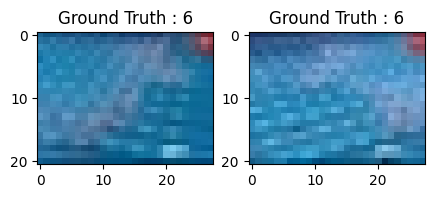

In [8]:
plt.figure(figsize=[5,5])

# Display the first image in training data
plt.subplot(121)
plt.imshow(train_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(train_Y[0]))

# Display the first image in testing data
plt.subplot(122)
plt.imshow(test_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(test_Y[0]))

# Preprocesamos las imagenes

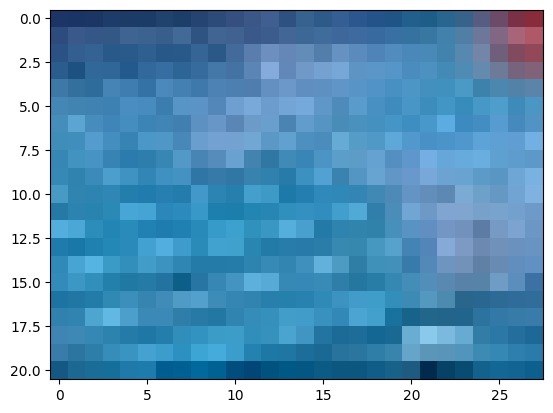

In [9]:
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X/255.
test_X = test_X/255.
plt.imshow(test_X[0,:,:])

## Hacemos el One-hot Encoding para la red

In [10]:
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Display the change for category label using one-hot encoding
print('Original label:', train_Y[0])
print('After conversion to one-hot:', train_Y_one_hot[0])

Original label: 6
After conversion to one-hot: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


# Creamos el Set de Entrenamiento y Validación

In [11]:
#Mezclar todo y crear los grupos de entrenamiento y testing
train_X,valid_X,train_label,valid_label = train_test_split(train_X, train_Y_one_hot, test_size=0.2, random_state=13)

In [12]:
print(train_X.shape,valid_X.shape,train_label.shape,valid_label.shape)

(49361, 21, 28, 3) (12341, 21, 28, 3) (49361, 10) (12341, 10)


# Creamos el modelo de CNN

In [13]:
#declaramos variables con los parámetros de configuración de la red
INIT_LR = 1e-3 # Valor inicial de learning rate. El valor 1e-3 corresponde con 0.001
epochs = 20 # Cantidad de iteraciones completas al conjunto de imagenes de entrenamiento
batch_size = 64 # cantidad de imágenes que se toman a la vez en memoria

In [14]:
sport_model = Sequential()
sport_model.add(Conv2D(32, kernel_size=(3, 3),activation='linear',padding='same',input_shape=(21,28,3)))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2),padding='same'))
sport_model.add(Dropout(0.5))

sport_model.add(Flatten())
sport_model.add(Dense(32, activation='linear'))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(Dropout(0.5))
sport_model.add(Dense(nClasses, activation='softmax'))

2026-03-22 04:21:25.544926: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-03-22 04:21:25.545110: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2026-03-22 04:21:25.545147: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (858d02d51065): /proc/driver/nvidia/version does not exist
2026-03-22 04:21:25.547477: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [15]:
sport_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 21, 28, 32)        896       
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 21, 28, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 11, 14, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 11, 14, 32)        0         
                                                                 
 flatten (Flatten)           (None, 4928)              0         
                                                                 
 dense (Dense)               (None, 32)                157728    
                                                        

In [16]:
sport_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adagrad(lr=INIT_LR, decay=INIT_LR / 100),metrics=['accuracy'])

/home/vscode/.local/lib/python3.10/site-packages/keras/optimizers/optimizer_v2/adagrad.py:81: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


# Entrenamos el modelo: Aprende a clasificar imágenes

In [17]:
# este paso puede tomar varios minutos, dependiendo de tu ordenador, cpu y memoria ram libre
sport_train = sport_model.fit(train_X, train_label, batch_size=batch_size,epochs=epochs,verbose=1,validation_data=(valid_X, valid_label))

Epoch 1/20
772/772 [==============================] - 21s 26ms/step - loss: 2.1507 - accuracy: 0.2055 - val_loss: 1.8876 - val_accuracy: 0.4254
Epoch 2/20
772/772 [==============================] - 19s 25ms/step - loss: 1.8532 - accuracy: 0.3497 - val_loss: 1.5719 - val_accuracy: 0.6016
Epoch 3/20
772/772 [==============================] - 22s 28ms/step - loss: 1.6425 - accuracy: 0.4459 - val_loss: 1.3593 - val_accuracy: 0.6682
Epoch 4/20
772/772 [==============================] - 21s 28ms/step - loss: 1.4968 - accuracy: 0.5006 - val_loss: 1.2260 - val_accuracy: 0.6852
Epoch 5/20
772/772 [==============================] - 29s 38ms/step - loss: 1.4031 - accuracy: 0.5369 - val_loss: 1.1318 - val_accuracy: 0.7042
Epoch 6/20
772/772 [==============================] - 25s 33ms/step - loss: 1.3299 - accuracy: 0.5600 - val_loss: 1.0608 - val_accuracy: 0.7289
Epoch 7/20
772/772 [==============================] - 21s 27ms/step - loss: 1.2673 - accuracy: 0.5822 - val_loss: 0.9996 - val_accuracy:

In [18]:
# guardamos la red, para reutilizarla en el futuro, sin tener que volver a entrenar
sport_model.save("sports_mnist.h5py")

INFO:tensorflow:Assets written to: sports_mnist.h5py/assets


INFO:tensorflow:Assets written to: sports_mnist.h5py/assets


# Evaluamos la red

In [19]:
test_eval = sport_model.evaluate(test_X, test_Y_one_hot, verbose=1)

483/483 [==============================] - 2s 5ms/step - loss: 0.6871 - accuracy: 0.8335


In [20]:
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 0.6871146559715271
Test accuracy: 0.8334630131721497


In [21]:
sport_train.history

{'loss': [2.150672674179077,
  1.8531869649887085,
  1.642460823059082,
  1.4967552423477173,
  1.4031163454055786,
  1.329852819442749,
  1.2672597169876099,
  1.2173699140548706,
  1.1787099838256836,
  1.1409956216812134,
  1.1102153062820435,
  1.0800597667694092,
  1.0645359754562378,
  1.0426347255706787,
  1.0222127437591553,
  1.005019187927246,
  0.9879000782966614,
  0.9746568202972412,
  0.9548711180686951,
  0.9449605941772461],
 'accuracy': [0.20554688572883606,
  0.3497295379638672,
  0.4458783268928528,
  0.5005571246147156,
  0.5369218587875366,
  0.5599562525749207,
  0.5821599960327148,
  0.5997244715690613,
  0.610522449016571,
  0.6246227025985718,
  0.6340228319168091,
  0.645347535610199,
  0.6520127058029175,
  0.6599339842796326,
  0.6648163795471191,
  0.670103907585144,
  0.6768704056739807,
  0.6820161938667297,
  0.6910313963890076,
  0.6943336129188538],
 'val_loss': [1.88755202293396,
  1.5718806982040405,
  1.3592936992645264,
  1.2259654998779297,
  1.13

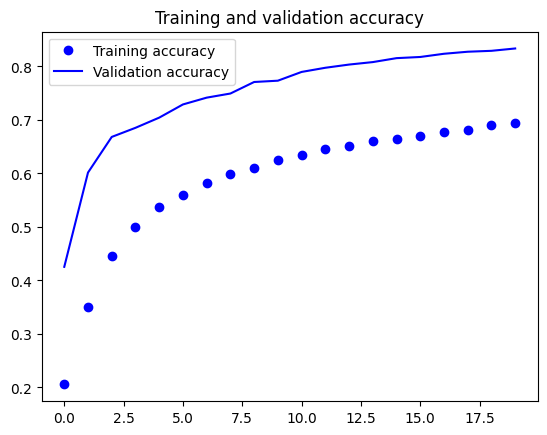

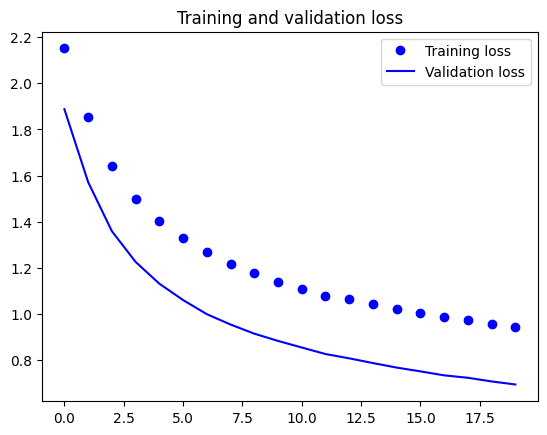

In [22]:
accuracy = sport_train.history['accuracy']
val_accuracy = sport_train.history['val_accuracy']
loss = sport_train.history['loss']
val_loss = sport_train.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [23]:
predicted_classes2 = sport_model.predict(test_X)

483/483 [==============================] - 3s 5ms/step


In [24]:
predicted_classes=[]
for predicted_sport in predicted_classes2:
    predicted_classes.append(predicted_sport.tolist().index(max(predicted_sport)))
predicted_classes=np.array(predicted_classes)

In [25]:
predicted_classes.shape, test_Y.shape

((15426,), (15426,))

# Aprendamos de los errores: Qué mejorar

Found 12857 correct labels


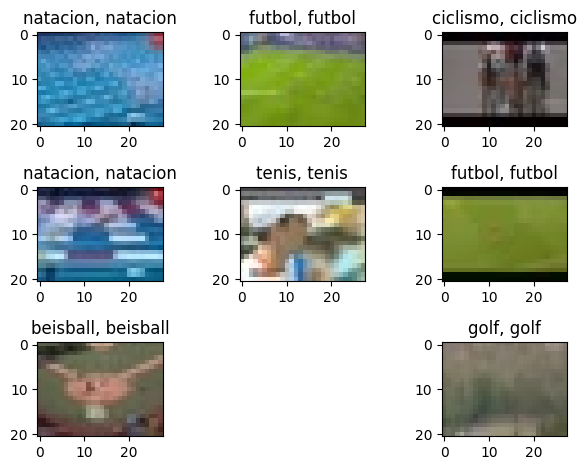

In [26]:
correct = np.where(predicted_classes==test_Y)[0]
print("Found %d correct labels" % len(correct))
for i, correct in enumerate(correct[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[correct].reshape(21,28,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[correct]],
                                                    deportes[test_Y[correct]]))

    plt.tight_layout()

Found 2569 incorrect labels


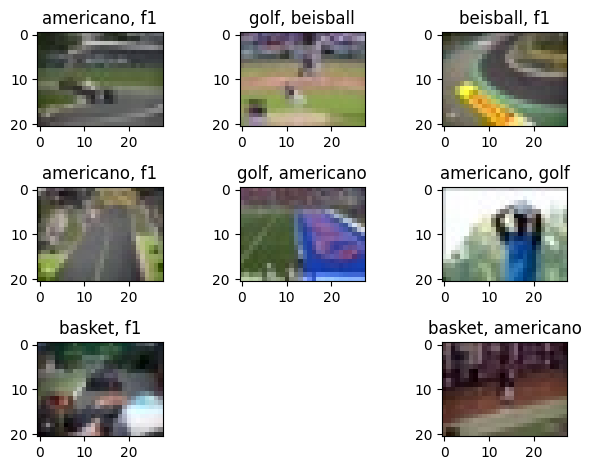

In [27]:
incorrect = np.where(predicted_classes!=test_Y)[0]
print("Found %d incorrect labels" % len(incorrect))
for i, incorrect in enumerate(incorrect[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[incorrect].reshape(21,28,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[incorrect]],
                                                    deportes[test_Y[incorrect]]))
    plt.tight_layout()

In [28]:
target_names = ["Class {}".format(i) for i in range(nClasses)]
print(classification_report(test_Y, predicted_classes, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.76      0.87      0.81      1771
     Class 1       0.68      0.87      0.77      1979
     Class 2       0.90      0.84      0.86      1571
     Class 3       0.97      0.99      0.98      1498
     Class 4       0.83      0.48      0.61       965
     Class 5       0.98      1.00      0.99      1772
     Class 6       0.91      0.92      0.91      1007
     Class 7       0.74      0.63      0.68      1908
     Class 8       0.85      0.91      0.88      1445
     Class 9       0.84      0.75      0.79      1510

    accuracy                           0.83     15426
   macro avg       0.85      0.82      0.83     15426
weighted avg       0.84      0.83      0.83     15426

